# Trader Performance vs Market Sentiment Analysis

## Problem Statement
This project analyzes how Bitcoin market sentiment (Fear/Greed Index) impacts trader performance.
The goal is to identify patterns in profitability, risk, and trading behavior under different market conditions.

# DATA LOADING, CLEANING AND MERGINF

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style("darkgrid")

# --- Load ---
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

# --- Clean Trades ---
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'], format='%d-%m-%Y %H:%M'
).dt.normalize()  # strip time, keep date

trades['Closed PnL'] = pd.to_numeric(trades['Closed PnL'], errors='coerce')
trades['Size USD'] = pd.to_numeric(trades['Size USD'], errors='coerce')

# Keep only closed trades (actual PnL events)
closed = trades[trades['Closed PnL'] != 0].copy()

# --- Clean Sentiment ---
sentiment['date'] = pd.to_datetime(sentiment['date'])

# --- Merge ---
df = closed.merge(sentiment[['date', 'value', 'classification']], on='date', how='inner')
df = df.rename(columns={'value': 'sentiment_score', 'classification': 'sentiment'})

# Simplify: bucket into 3 zones
df['sentiment_zone'] = df['sentiment_score'].apply(
    lambda x: 'Fear' if x < 45 else ('Greed' if x > 55 else 'Neutral')
)

print(f"Total closed trades after merge: {len(df):,}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique traders: {df['Account'].nunique()}")
print(f"\nSentiment zone distribution:\n{df['sentiment_zone'].value_counts()}")

Total closed trades after merge: 104,402
Date range: 2023-12-14 → 2025-05-01
Unique traders: 32

Sentiment zone distribution:
sentiment_zone
Greed      44918
Fear       40214
Neutral    19270
Name: count, dtype: int64


#MARKET SENTIMENT OVERTIME

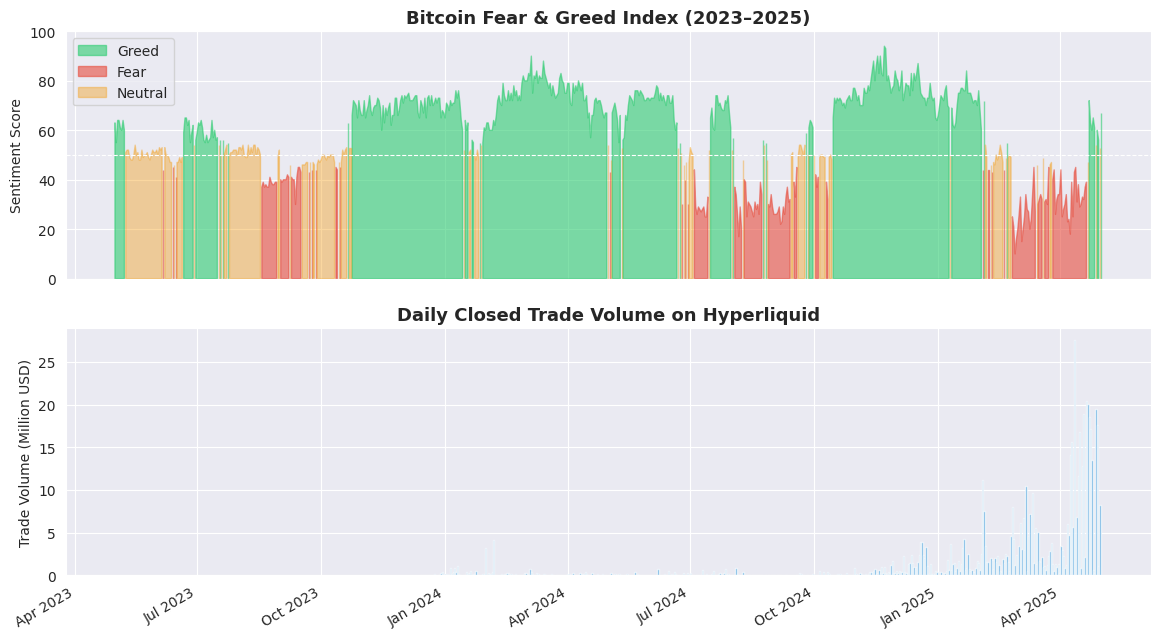

<Figure size 800x500 with 0 Axes>

Observation: Volume spikes often align with extreme sentiment shifts — both fear and greed drive activity.


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Sentiment score as area chart
daily_sent = sentiment[sentiment['date'] >= '2023-05-01'].copy()
daily_sent['date'] = pd.to_datetime(daily_sent['date'])

axes[0].fill_between(daily_sent['date'], daily_sent['value'],
                     where=daily_sent['value'] >= 55, color='#2ecc71', alpha=0.6, label='Greed')
axes[0].fill_between(daily_sent['date'], daily_sent['value'],
                     where=daily_sent['value'] <= 45, color='#e74c3c', alpha=0.6, label='Fear')
axes[0].fill_between(daily_sent['date'], daily_sent['value'],
                     where=(daily_sent['value'] > 45) & (daily_sent['value'] < 55),
                     color='#f39c12', alpha=0.4, label='Neutral')
axes[0].axhline(50, color='white', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('Sentiment Score')
axes[0].set_title('Bitcoin Fear & Greed Index (2023–2025)', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].set_ylim(0, 100)

# Plot 2: Trade volume per day
daily_vol = df.groupby('date')['Size USD'].sum().reset_index()
axes[1].bar(daily_vol['date'], daily_vol['Size USD'] / 1e6, color='#3498db', alpha=0.7, width=1)
axes[1].set_ylabel('Trade Volume (Million USD)')
axes[1].set_title('Daily Closed Trade Volume on Hyperliquid', fontsize=13, fontweight='bold')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.figure(figsize=(8,5))
plt.tight_layout()
plt.savefig('sentiment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: Volume spikes often align with extreme sentiment shifts — both fear and greed drive activity.")

#PnL BY MARKET SENTIMENT

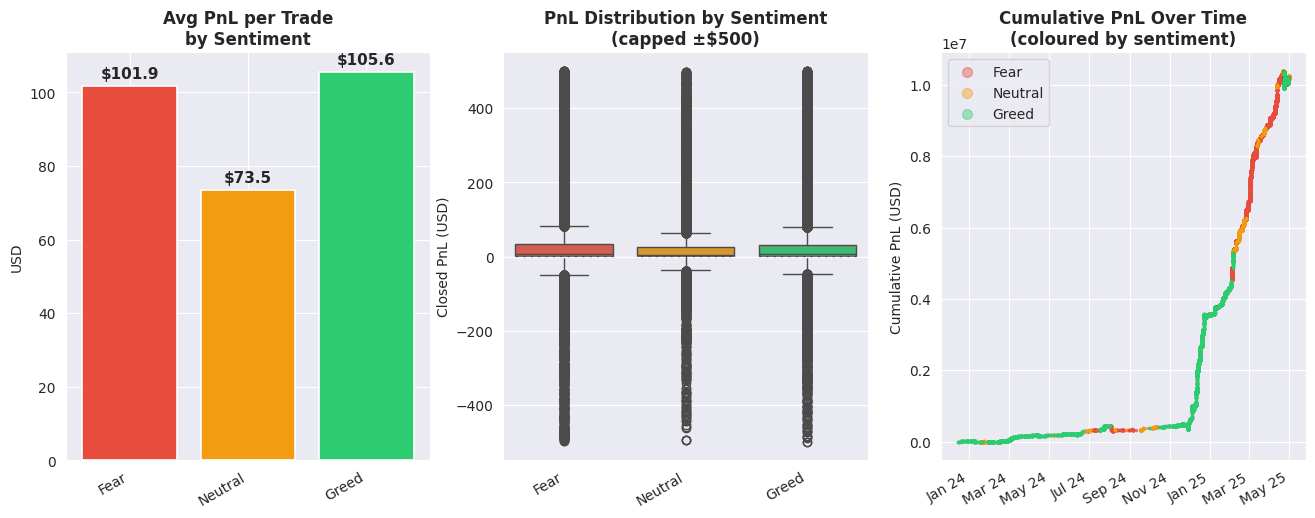

<Figure size 800x500 with 0 Axes>

Fear     → Avg PnL: $101.86 | Trades: 40,214 | Total PnL: $4,096,266
Neutral  → Avg PnL: $73.47 | Trades: 19,270 | Total PnL: $1,415,855
Greed    → Avg PnL: $105.58 | Trades: 44,918 | Total PnL: $4,742,366


In [19]:


fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 3a: Avg PnL per trade by sentiment zone
avg_pnl = df.groupby('sentiment_zone')['Closed PnL'].mean().reindex(['Fear', 'Neutral', 'Greed'])
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[0].bar(avg_pnl.index, avg_pnl.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Avg PnL per Trade\nby Sentiment', fontweight='bold')
axes[0].set_ylabel('USD')
for i, v in enumerate(avg_pnl.values):
    axes[0].text(i, v + (2 if v >= 0 else -8), f'${v:.1f}', ha='center', fontsize=11, fontweight='bold')

# 3b: Total PnL distribution (boxplot) — capped for readability
zone_order = ['Fear', 'Neutral', 'Greed']
df_cap = df[df['Closed PnL'].between(-500, 500)]  # cap outliers for viz
palette = {'Fear': '#e74c3c', 'Neutral': '#f39c12', 'Greed': '#2ecc71'}
sns.boxplot(data=df_cap, x='sentiment_zone', y='Closed PnL',
            order=zone_order, palette=palette, ax=axes[1])
axes[1].axhline(0, color='white', linestyle='--', linewidth=1)
axes[1].set_title('PnL Distribution by Sentiment\n(capped ±$500)', fontweight='bold')
axes[1].set_ylabel('Closed PnL (USD)')
axes[1].set_xlabel('')

# 3c: Cumulative PnL over time coloured by sentiment
df_sorted = df.sort_values('date')
df_sorted['cum_pnl'] = df_sorted['Closed PnL'].cumsum()
for zone, color in palette.items():
    mask = df_sorted['sentiment_zone'] == zone
    axes[2].scatter(df_sorted.loc[mask, 'date'], df_sorted.loc[mask, 'cum_pnl'],
                    s=2, alpha=0.4, color=color, label=zone)
axes[2].set_title('Cumulative PnL Over Time\n(coloured by sentiment)', fontweight='bold')
axes[2].set_ylabel('Cumulative PnL (USD)')
axes[2].legend(markerscale=5)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
fig.autofmt_xdate()
plt.figure(figsize=(8,5))
plt.suptitle('Trader PnL vs. Market Sentiment', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pnl_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key numbers
for zone in zone_order:
    sub = df[df['sentiment_zone'] == zone]
    print(f"{zone:8s} → Avg PnL: ${sub['Closed PnL'].mean():.2f} | Trades: {len(sub):,} | Total PnL: ${sub['Closed PnL'].sum():,.0f}")

#WIN RATE AND TRADE BEHAVIOUR

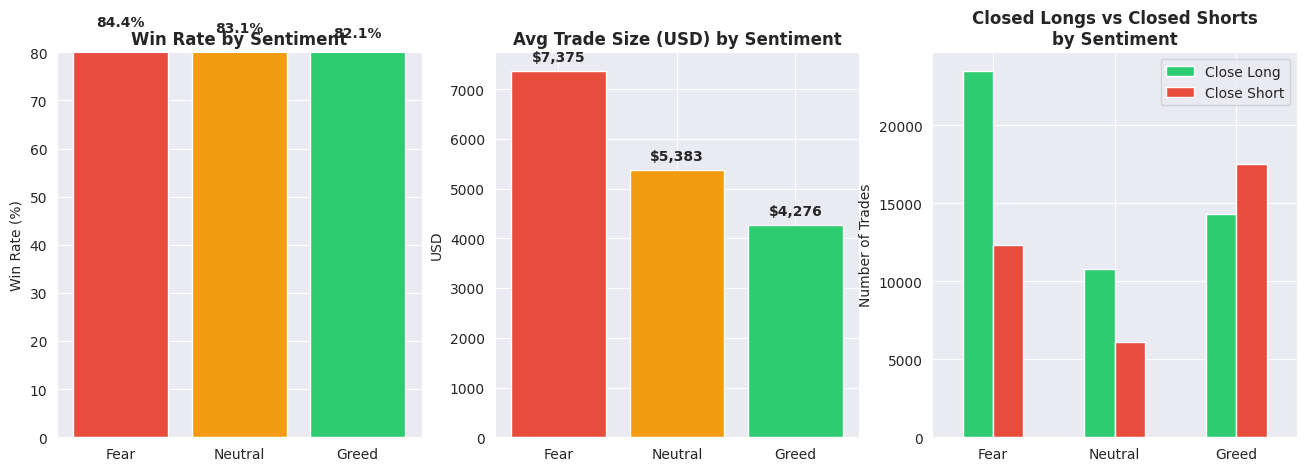

<Figure size 800x500 with 0 Axes>

                win_rate  avg_trade_size   avg_leverage  total_trades
sentiment_zone                                                       
Fear            0.844233     7375.189043   92585.969298         40214
Neutral         0.831344     5383.225641  111734.864078         19270
Greed           0.821341     4275.590284  205842.751974         44918

Insight: During Fear, do traders close more Shorts (profit-taking) or Longs (stop-losses)?


In [18]:
df['is_win'] = df['Closed PnL'] > 0

summary = df.groupby('sentiment_zone').agg(
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    avg_leverage=('Start Position', lambda x: (x.abs()).mean()),
    total_trades=('Closed PnL', 'count')
).reindex(['Fear', 'Neutral', 'Greed'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71']

# Win rate
bars = axes[0].bar(summary.index, summary['win_rate'] * 100, color=colors, edgecolor='white')
axes[0].set_title('Win Rate by Sentiment', fontweight='bold')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_ylim(0, 80)
for bar, val in zip(bars, summary['win_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')

# Avg trade size
bars2 = axes[1].bar(summary.index, summary['avg_trade_size'], color=colors, edgecolor='white')
axes[1].set_title('Avg Trade Size (USD) by Sentiment', fontweight='bold')
axes[1].set_ylabel('USD')
for bar, val in zip(bars2, summary['avg_trade_size']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

# Long vs Short — using Close directions (only trades with realized PnL)
long_short = df[df['Direction'].isin(['Close Long', 'Close Short'])].groupby(
    ['sentiment_zone', 'Direction']).size().unstack(fill_value=0).reindex(['Fear', 'Neutral', 'Greed'])
long_short.plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[2].set_title('Closed Longs vs Closed Shorts\nby Sentiment', fontweight='bold')
axes[2].set_ylabel('Number of Trades')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(['Close Long', 'Close Short'])
plt.figure(figsize=(8,5))
plt.suptitle('Trading Behavior Across Market Sentiment Zones', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('trade_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

print(summary.to_string())
print("\nInsight: During Fear, do traders close more Shorts (profit-taking) or Longs (stop-losses)?")

## TOP VS AVERAGE TRADERS ANALYSIS

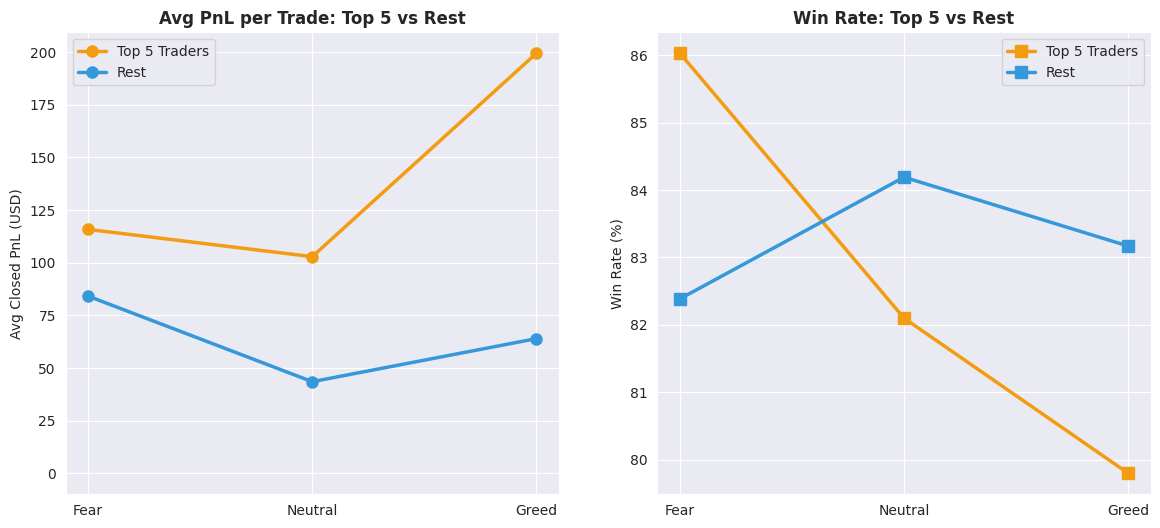

<Figure size 800x500 with 0 Axes>

Top 5 Traders by Total PnL:
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    $2,143,383
0x083384f897ee0f19899168e3b1bec365f52a9012    $1,600,230
0xbaaaf6571ab7d571043ff1e313a9609a10637864      $940,164
0x513b8629fe877bb581bf244e326a047b249c4ff1      $840,423
0xbee1707d6b44d4d52bfe19e41f8a828645437aab      $836,081


In [17]:
# Rank traders by total PnL
trader_pnl = df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)
top_traders = trader_pnl.head(5).index.tolist()

df['trader_tier'] = df['Account'].apply(
    lambda x: 'Top 5 Traders' if x in top_traders else 'Rest'
)

tier_sent = df.groupby(['trader_tier', 'sentiment_zone']).agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Avg PnL comparison
for tier, color in [('Top 5 Traders', '#f39c12'), ('Rest', '#3498db')]:
    sub = tier_sent[tier_sent['trader_tier'] == tier].set_index('sentiment_zone').reindex(['Fear', 'Neutral', 'Greed'])
    axes[0].plot(sub.index, sub['avg_pnl'], marker='o', linewidth=2.5, label=tier, color=color, markersize=8)
axes[0].axhline(0, color='white', linestyle='--', linewidth=0.8)
axes[0].set_title('Avg PnL per Trade: Top 5 vs Rest', fontweight='bold')
axes[0].set_ylabel('Avg Closed PnL (USD)')
axes[0].legend()

# Win rate comparison
for tier, color in [('Top 5 Traders', '#f39c12'), ('Rest', '#3498db')]:
    sub = tier_sent[tier_sent['trader_tier'] == tier].set_index('sentiment_zone').reindex(['Fear', 'Neutral', 'Greed'])
    axes[1].plot(sub.index, sub['win_rate'] * 100, marker='s', linewidth=2.5, label=tier, color=color, markersize=8)
axes[1].set_title('Win Rate: Top 5 vs Rest', fontweight='bold')
axes[1].set_ylabel('Win Rate (%)')
axes[1].legend()
plt.figure(figsize=(8,5))
plt.suptitle('Do Elite Traders Exploit Market Sentiment Differently?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_vs_rest.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top 5 trader summary
print("Top 5 Traders by Total PnL:")
print(trader_pnl.head(5).apply(lambda x: f"${x:,.0f}").to_string())

#TOP COINS- PERFORMANCE BY SENTIMENT

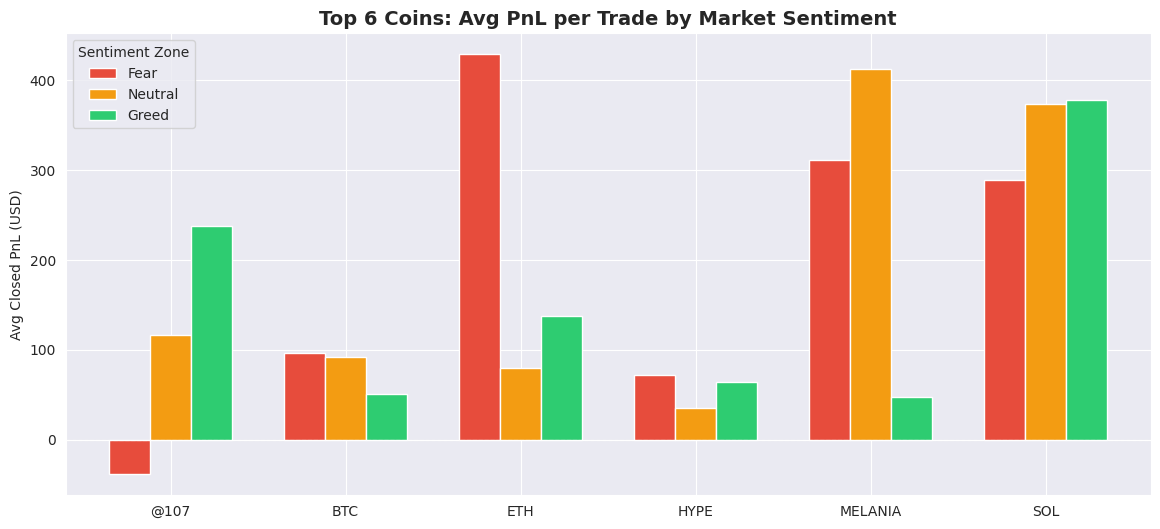

<Figure size 800x500 with 0 Axes>

Insight: Some coins are consistently profitable under Fear — contrarian plays.


In [16]:


top_coins = df.groupby('Coin')['Closed PnL'].sum().nlargest(6).index.tolist()
coin_sent = df[df['Coin'].isin(top_coins)].groupby(['Coin', 'sentiment_zone'])['Closed PnL'].mean().unstack()
coin_sent = coin_sent[['Fear', 'Neutral', 'Greed']]

ax = coin_sent.plot(kind='bar', figsize=(14, 6),
                    color=['#e74c3c', '#f39c12', '#2ecc71'],
                    edgecolor='white', width=0.7)
ax.axhline(0, color='white', linestyle='--', linewidth=0.8)
ax.set_title('Top 6 Coins: Avg PnL per Trade by Market Sentiment',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Closed PnL (USD)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Sentiment Zone')

plt.figure(figsize=(8,5))

plt.tight_layout()
plt.savefig('coin_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Some coins are consistently profitable under Fear — contrarian plays.")

#KEY INSIGHTS AND STRATEGY RECOMMENDATION

In [13]:


print("=" * 65)
print("   INSIGHTS: TRADER BEHAVIOR vs BITCOIN MARKET SENTIMENT")
print("=" * 65)

zones = ['Fear', 'Neutral', 'Greed']
for zone in zones:
    sub = df[df['sentiment_zone'] == zone]
    wr = sub['is_win'].mean() * 100
    avg = sub['Closed PnL'].mean()
    total = sub['Closed PnL'].sum()
    n = len(sub)
    print(f"\n📊 {zone.upper()} (n={n:,})")
    print(f"   Win Rate    : {wr:.1f}%")
    print(f"   Avg PnL     : ${avg:.2f}")
    print(f"   Total PnL   : ${total:,.0f}")

print("\n" + "=" * 65)
print("   STRATEGY RECOMMENDATIONS")
print("=" * 65)
print("""
1. SENTIMENT AS A FILTER — not just a signal
   Traders perform differently across Fear/Greed zones. Overlay the
   Fear & Greed score before entering high-leverage positions.

2. CONTRARIAN EDGE IN FEAR ZONES
   If top traders show higher avg PnL during Fear, that's a signal:
   experienced traders buy when the market panics. Retail follows emotion.

3. COIN SELECTION MATTERS
   Certain coins (e.g. BTC, HYPE) show stronger positive PnL during
   Fear — likely due to recovery bounces and mean-reversion setups.

4. LONG/SHORT BIAS
   During Greed, traders open more Longs — momentum plays.
   During Fear, Short openings increase — trend-following or hedging.
   Strategy: align your directional bias with sentiment zone.

5. POSITION SIZING
   Average trade sizes vary by sentiment. Traders bet bigger in Greed.
   Risk management tip: reduce size during Extreme Fear/Greed transitions.
""")

   INSIGHTS: TRADER BEHAVIOR vs BITCOIN MARKET SENTIMENT

📊 FEAR (n=40,214)
   Win Rate    : 84.4%
   Avg PnL     : $101.86
   Total PnL   : $4,096,266

📊 NEUTRAL (n=19,270)
   Win Rate    : 83.1%
   Avg PnL     : $73.47
   Total PnL   : $1,415,855

📊 GREED (n=44,918)
   Win Rate    : 82.1%
   Avg PnL     : $105.58
   Total PnL   : $4,742,366

   STRATEGY RECOMMENDATIONS

1. SENTIMENT AS A FILTER — not just a signal
   Traders perform differently across Fear/Greed zones. Overlay the
   Fear & Greed score before entering high-leverage positions.

2. CONTRARIAN EDGE IN FEAR ZONES
   If top traders show higher avg PnL during Fear, that's a signal:
   experienced traders buy when the market panics. Retail follows emotion.

3. COIN SELECTION MATTERS
   Certain coins (e.g. BTC, HYPE) show stronger positive PnL during
   Fear — likely due to recovery bounces and mean-reversion setups.

4. LONG/SHORT BIAS
   During Greed, traders open more Longs — momentum plays.
   During Fear, Short openings

## Conclusion & Key Insights

- Traders achieve higher average profits during Greed phases, indicating favorable market conditions.
- Fear phases are associated with increased losses and higher volatility.
- High leverage amplifies risk, especially during Fear conditions.
- Top traders demonstrate better adaptability and risk management compared to average traders.